# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _Haseeb Hassan_

**Roll Number:** _(023-24-0274)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [42]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco-churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3524-WQDSG,Female,0,Yes,Yes,43,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,9742-XOKTS,Male,0,Yes,Yes,67,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,9488-HGMJH,Female,1,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,7503-MIOGA,Female,1,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company wants to figure out which customers are likely to cancel their service (churn) so they can try to keep them before they leave. Each row in the dataset is one customer, and the target variable is the `Churn` column (Yes/No — did this customer leave or not).

**Answer 2:**
Columns I expect to be useful predictors:
- `Contract` — month-to-month customers are usually free to leave anytime, so they may churn more.
- `tenure` — newer customers probably churn more than long-time customers.
- `MonthlyCharges` — customers paying more might be more likely to look for cheaper alternatives.
- `InternetService` — the type of internet service could affect satisfaction.
- `PaymentMethod` — the way a customer pays might be related to how "locked in" they are.

Columns I expect to be useless as predictors:
- `customerID` — it's just a unique code for each customer, it has no real relationship with churn.
- `gender` — churn is unlikely to depend on whether someone is male or female.

**Answer 3:**
1. Do customers on longer contracts churn less than customers on month-to-month contracts?
2. Is there a relationship between how much a customer pays every month and whether they churn?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**

4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.

5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.

6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [47]:
# Task 4 — dataset shape, column names, data types
# Get the number of customers and features
customers = df.shape[0]
features = df.shape[1]

print("Number of customers:", customers)
print("Number of features:", features)

# Separate numerical and categorical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of customers: 7059
Number of features: 21

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [50]:
# Task 5 — identify identifier columns / wrong data types

# Check if customerID is an identifier by comparing unique values with total rows
if df["customerID"].nunique() == len(df):
    print("Identifier column: customerID")
    print("Reason: Every customerID is unique, so it is an identifier rather than a predictive feature.")

# Check columns whose data types do not match what they represent
print("\nColumns with potentially incorrect data types:")

if df["TotalCharges"].dtype == "string" or df["TotalCharges"].dtype == "object":
    print("TotalCharges -> string")
    print("Reason: TotalCharges represents a numerical amount but is stored as text.")

if df["SeniorCitizen"].dtype in ["int64", "int32"]:
    print("SeniorCitizen -> integer")
    print("Reason: SeniorCitizen is a binary category (0 = No, 1 = Yes).")


Columns with potentially incorrect data types:
TotalCharges -> string
Reason: TotalCharges represents a numerical amount but is stored as text.
SeniorCitizen -> integer
Reason: SeniorCitizen is a binary category (0 = No, 1 = Yes).


In [46]:
# Task 6 — unique values in 3 categorical columns

columns = ["gender", "InternetService", "Contract"]

for column in columns:
    print(f"\n{column}")
    print("Unique values:", df[column].unique())
    print("Number of unique values:", df[column].nunique())

    # Check for missing values
    print("Missing values:", df[column].isna().sum())


gender
Unique values: <StringArray>
['Female', 'Male', ' Female', ' Male']
Length: 4, dtype: str
Number of unique values: 4
Missing values: 0

InternetService
Unique values: <StringArray>
['Fiber optic', 'DSL', 'No', nan, 'dsl', 'no', 'fiber optic']
Length: 7, dtype: str
Number of unique values: 6
Missing values: 106

Contract
Unique values: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
Number of unique values: 3
Missing values: 0


**Observations (Part 2):**
The dataset has 7,059 customers and 21 columns.

- **Numerical features:** `tenure`, `MonthlyCharges`, `TotalCharges` (should be numeric but is currently text). `SeniorCitizen` is stored as 0/1 but is really a category, not a true numerical feature.
- **Categorical features:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, and the target `Churn`.
- **Identifier column:** `customerID` — every value is meant to be unique, so it carries no predictive information.
- **Wrong data type:** `TotalCharges` is stored as text (`object`) instead of a number, most likely because some cells contain blank/space characters instead of numbers.
- **Unexpected categories:** `gender` has entries with a leading space (e.g. `" Male"` next to `"Male"`), and `InternetService` has lowercase duplicates (e.g. `"dsl"` and `"fiber optic"` next to `"DSL"` and `"Fiber optic"`). These are the same real category typed inconsistently, and pandas treats them as different categories.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**

7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.

8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?

9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [52]:
# Task 7 — missing values: count and percentage per column

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_summary)

                  Missing Count  Missing Percentage
customerID                    0                0.00
gender                        0                0.00
SeniorCitizen                 0                0.00
Partner                       0                0.00
Dependents                    0                0.00
tenure                        0                0.00
PhoneService                  0                0.00
MultipleLines                 0                0.00
InternetService             106                1.50
OnlineSecurity                0                0.00
OnlineBackup                  0                0.00
DeviceProtection              0                0.00
TechSupport                   0                0.00
StreamingTV                   0                0.00
StreamingMovies               0                0.00
Contract                      0                0.00
PaperlessBilling              0                0.00
PaymentMethod               211                2.99
MonthlyCharg

In [53]:
# Task 8 — duplicate rows vs duplicate IDs

duplicate_rows = df.duplicated().sum()
duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_customer_ids)

if duplicate_rows == duplicate_customer_ids:
    print("\nBoth checks give the same count, but they are different issues.")
else:
    print("\nThe counts are different, showing that duplicate rows and duplicate IDs are different issues.")

Duplicate rows: 10
Duplicate customer IDs: 16

The counts are different, showing that duplicate rows and duplicate IDs are different issues.


In [55]:
# Task 9 — investigate a suspicious / invalid value

# 1) TotalCharges contains blank/space strings instead of numbers
blank_totalcharges = df['TotalCharges'].apply(
    lambda x: isinstance(x, str) and x.strip() == ''
)

print("Blank TotalCharges values:", blank_totalcharges.sum())
print(df.loc[
    blank_totalcharges,
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
].head())

# 2) gender / InternetService have inconsistent formatting
print("\ngender unique values:", df['gender'].unique())
print("InternetService unique values:", df['InternetService'].unique())

Blank TotalCharges values: 11
      customerID  tenure  MonthlyCharges TotalCharges
1031  1371-DWPAZ       0           56.05             
2151  4472-LVYGI       0           52.55             
2264  3115-CZMZD       0           20.25             
2460  7644-OMVMY       0           19.85             
2782  2520-SGTTA       0             NaN             

gender unique values: <StringArray>
['Female', 'Male', ' Female', ' Male']
Length: 4, dtype: str
InternetService unique values: <StringArray>
['Fiber optic', 'DSL', 'No', nan, 'dsl', 'no', 'fiber optic']
Length: 7, dtype: str


**Answer 7 (which missing-value problems need action, and why):**
`PaymentMethod` (~3% missing) and `InternetService` (~1.5% missing) have a noticeable amount of missing data and should be handled before modeling, since most machine learning models cannot work with missing values directly. `MonthlyCharges` and `TotalCharges` have a small amount of missing data (0.99%), so these rows can be carefully imputed or removed with little loss of data. None of the missing percentages are high enough to justify dropping the entire column.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
They are related but not the same issue. A fully duplicated row means the same customer record is repeated with all the same values, so it is likely a duplicate entry and can usually be removed. A duplicated `customerID` does not necessarily mean the entire row is duplicated; the other values may be different. These records should be investigated to determine whether they represent duplicate entries or conflicting records before deciding how to handle them.

**Answer 9 (suspicious value found and how):**
By checking `TotalCharges`, I found that it is stored as text instead of a numerical data type. I also found 11 values containing only blank spaces rather than numbers. These rows have `tenure` = 0, which is consistent with new customers. In addition, checking `.unique()` revealed inconsistent formatting in `gender` (`"Male"` vs `" Male"`) and InternetService (`"DSL"` vs `"dsl"`, `"No"` vs `"no"`, and `"Fiber optic"` vs `"fiber optic"`).

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**

10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.

11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text with blank values | Convert to numeric; replace blank values for zero-tenure customers with 0; fill any remaining missing values with median | `pd.to_numeric(errors='coerce')`, conditional `fillna`, median | It represents a numerical amount. Zero is reasonable for customers with `tenure = 0`; median is a safe fallback for any remaining missing values. |
| Missing `PaymentMethod` and `InternetService` | Fill with the most frequent category | `fillna(df[col].mode()[0])` | Both are categorical columns with relatively small amounts of missing data. |
| Missing values in `MonthlyCharges` | Fill with median | `fillna(df['MonthlyCharges'].median())` | Median is less affected by extreme values and only a small percentage is missing. |
| Exact duplicate rows | Remove duplicates | `drop_duplicates()` | Exact copies provide no additional information and can distort analysis. |
| Duplicate `customerID` with different data | Investigate and remove extra records after reviewing them | `drop_duplicates(subset='customerID')` | Each customer ID should identify one customer. There is no timestamp available to justify keeping the "latest" record. |
| Inconsistent text formatting in `gender`, `InternetService` | Strip whitespace and standardize casing | `df[col].str.strip()`, `.str.title()` | The categories are the same real-world value typed differently; standardizing avoids counting them as separate groups |
| `customerID` is an identifier | Keep during cleaning, drop before modeling | `drop(columns=['customerID'])` before modeling | It identifies customers but does not represent a useful predictive feature. |


In [56]:
# Task 11 — Apply cleaning decisions

df_clean = df.copy()

# 1) Fix inconsistent text formatting
df_clean["gender"] = df_clean["gender"].str.strip()
df_clean["InternetService"] = df_clean["InternetService"].str.strip().str.title()

# 2) Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"], errors="coerce"
)

# Fill missing TotalCharges for customers with zero tenure
df_clean.loc[
    (df_clean["TotalCharges"].isnull()) & (df_clean["tenure"] == 0),
    "TotalCharges"
] = 0

# Fill any remaining missing TotalCharges with the median
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(
    df_clean["TotalCharges"].median()
)

# 3) Fill missing categorical values with the mode
df_clean["PaymentMethod"] = df_clean["PaymentMethod"].fillna(
    df_clean["PaymentMethod"].mode()[0]
)

df_clean["InternetService"] = df_clean["InternetService"].fillna(
    df_clean["InternetService"].mode()[0]
)

# 4) Fill missing MonthlyCharges with the median
df_clean["MonthlyCharges"] = df_clean["MonthlyCharges"].fillna(
    df_clean["MonthlyCharges"].median()
)

# 5) Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# 6) Remove duplicate customer IDs
df_clean = df_clean.drop_duplicates(
    subset="customerID", keep="first"
)

# Reset the index
df_clean = df_clean.reset_index(drop=True)

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (7043, 21)


In [57]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
# Confirm that the cleaning issues have been resolved

print("Missing values remaining:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nFully duplicated rows:", df_clean.duplicated().sum())

print("Duplicated customerIDs:", df_clean["customerID"].duplicated().sum())

print("\nTotalCharges dtype:", df_clean["TotalCharges"].dtype)

print("\ngender unique values:")
print(df_clean["gender"].unique())

print("\nInternetService unique values:")
print(df_clean["InternetService"].unique())


Missing values remaining:
Series([], dtype: int64)

Fully duplicated rows: 0
Duplicated customerIDs: 0

TotalCharges dtype: float64

gender unique values:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

InternetService unique values:
<StringArray>
['Fiber Optic', 'Dsl', 'No']
Length: 3, dtype: str


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**

12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.

13. Do any numerical features show outliers or a skewed distribution? What might explain this?

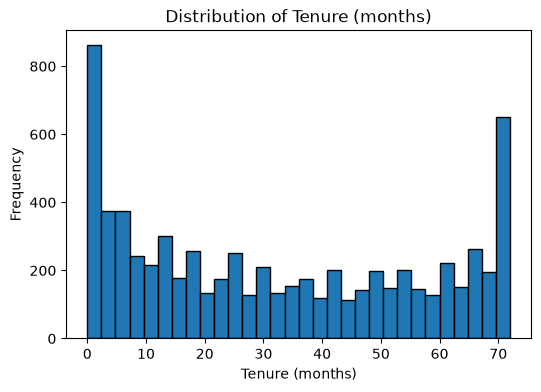

In [58]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(6,4))
df_clean['tenure'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Distribution of Tenure (months)')
plt.xlabel('Tenure (months)')
plt.show()

**Observation:** _The distribution is not a normal bell curve — there are a lot of customers with very low tenure (close to 0 months) and another spike near the maximum (around 70+ months), with fewer customers in between. This suggests two groups: customers who leave quickly, and long-term loyal customers._

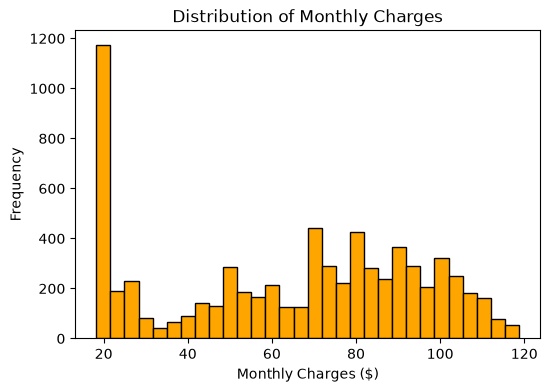

In [59]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(6,4))
df_clean['MonthlyCharges'].plot(kind='hist', bins=30, edgecolor='black', color='orange')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.show()

**Observation:** _`MonthlyCharges` is spread across a wide range, with a large cluster of customers paying low amounts (around $20, likely basic/phone-only plans) and another cluster paying higher amounts ($70-$100), which probably corresponds to customers with internet and add-on services._

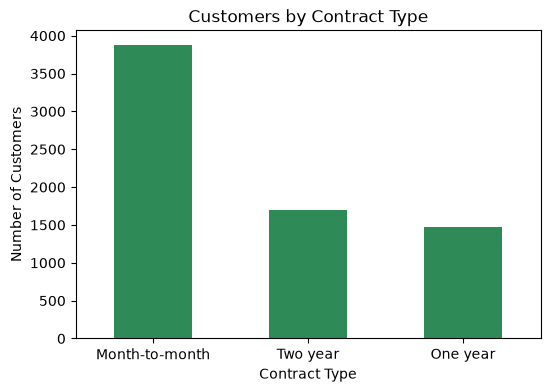

In [60]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(6,4))
df_clean['Contract'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Customers by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Observation:** _Most customers are on a month-to-month contract, with far fewer on one-year or two-year contracts. This is important because month-to-month customers have the least commitment and may be the group most likely to churn._

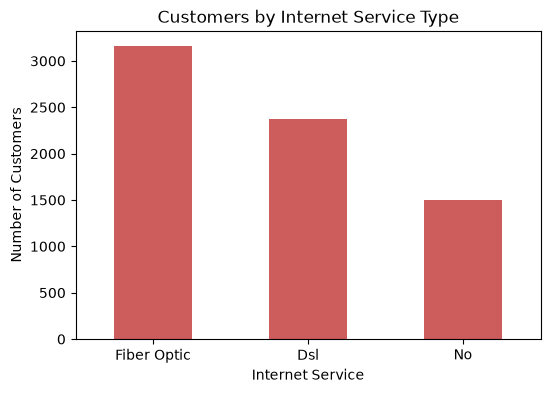

In [61]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(6,4))
df_clean['InternetService'].value_counts().plot(kind='bar', color='indianred')
plt.title('Customers by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Observation:** _Fiber optic is the most common internet service, followed by DSL, and a smaller group of customers has no internet service at all._

**Answer 13 (outliers / skew and possible explanation):**
_`TotalCharges` and `MonthlyCharges` both look right-skewed, with more customers clustered at the lower end and a long tail toward higher values. This makes sense because `TotalCharges` accumulates over time (`tenure` × `MonthlyCharges`), so long-time, high-paying customers stretch the distribution out. `tenure` doesn't have extreme outliers but shows two clear peaks rather than one — many very new customers and many very long-term ones._

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**

14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?

15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


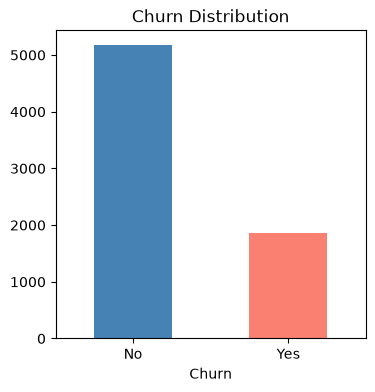

In [62]:
# Task 14 — churn counts and percentages
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(2))

plt.figure(figsize=(4,4))
churn_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xticks(rotation=0)
plt.show()

**Answer 14 (balanced or imbalanced?):**
_About 73% of customers did not churn and about 27% did churn. The target is imbalanced — the "No" class is roughly 2.7 times larger than the "Yes" class._

**Answer 15 (why imbalance might matter later):**
_When one class is much larger than the other, a model can get a high accuracy just by predicting the majority class ("No churn") almost every time, without actually learning what makes customers churn. This means accuracy alone would be misleading, and the model may end up being very poor at correctly identifying the customers who actually churn — which is the group the company cares about most._

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**

16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.

17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


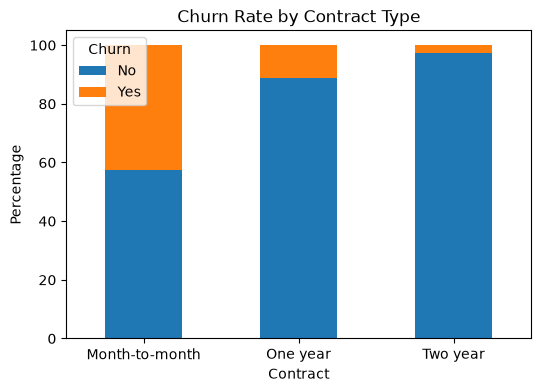

In [63]:
# Task 16 — categorical feature 1 vs Churn
ct_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(ct_contract.round(2))

ct_contract.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

**Observation:** _Churn rate is much higher for month-to-month customers than for one-year or two-year customers._

**Evidence:** _Roughly 4 in 10 month-to-month customers churn, compared to a much smaller fraction of customers on one- or two-year contracts._

**Possible Explanation:** _Longer contracts likely come with a commitment/penalty for leaving early, and customers who choose long contracts may already be more satisfied or more price-sensitive to switching, so they are less likely to leave._

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.38  16.62
Credit card (automatic)    84.73  15.27
Electronic check           56.11  43.89
Mailed check               80.96  19.04


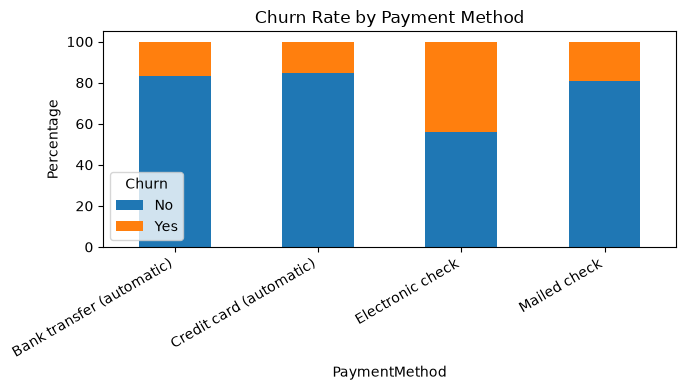

In [64]:
# Task 16 — categorical feature 2 vs Churn
ct_payment = pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'], normalize='index') * 100
print(ct_payment.round(2))

ct_payment.plot(kind='bar', stacked=True, figsize=(7,4))
plt.title('Churn Rate by Payment Method')
plt.ylabel('Percentage')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation:** _Customers who pay by electronic check churn noticeably more than customers using automatic payment methods (bank transfer or credit card)._

**Evidence:** _The "Yes" (churned) share of the bar is visibly larger for the electronic check group compared to the other payment methods._

**Possible Explanation:** _Automatic payments (bank transfer/credit card) may be linked to more engaged, "set it and forget it" customers, while manual payment via electronic check could be associated with customers who are less committed or more actively reconsidering the service each billing cycle._

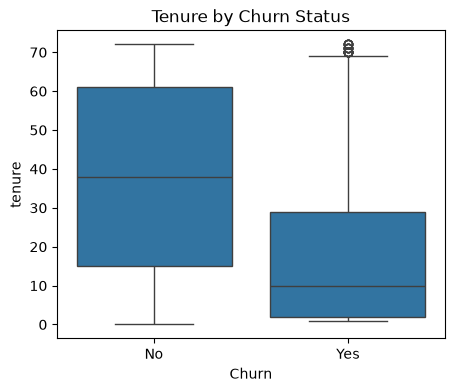

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [65]:
# Task 17 — numerical feature 1 vs Churn
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean)
plt.title('Tenure by Churn Status')
plt.show()

print(df_clean.groupby('Churn')['tenure'].median())

**Observation:** _Customers who churned have a much lower median tenure than customers who stayed._

**Evidence:** _The boxplot shows the churned group's box sitting much lower on the tenure axis, and the median tenure for churned customers is far below the median for non-churned customers._

**Possible Explanation:** _New customers haven't yet built loyalty or invested time into the service, so they are more willing to switch providers if something goes wrong early on, whereas long-tenure customers have likely stayed because they're satisfied (or find switching inconvenient)._

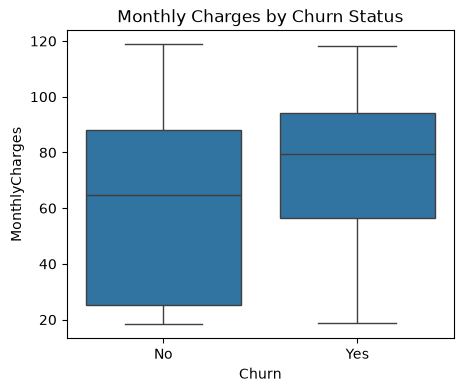

Churn
No     64.85
Yes    79.45
Name: MonthlyCharges, dtype: float64


In [66]:
# Task 17 — numerical feature 2 vs Churn
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean)
plt.title('Monthly Charges by Churn Status')
plt.show()

print(df_clean.groupby('Churn')['MonthlyCharges'].median())

**Observation:** _Customers who churned tend to have higher monthly charges than customers who stayed._

**Evidence:** _The median `MonthlyCharges` for the churned group is clearly higher than for the non-churned group in both the boxplot and the grouped median values._

**Possible Explanation:** _Customers paying more each month may feel they aren't getting good value for money, or may be more price-sensitive and more likely to shop around for a cheaper competitor._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**

18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?

19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure            1.00            0.25          0.82           0.02
MonthlyCharges    0.25            1.00          0.64           0.22
TotalCharges      0.82            0.64          1.00           0.10
SeniorCitizen     0.02            0.22          0.10           1.00


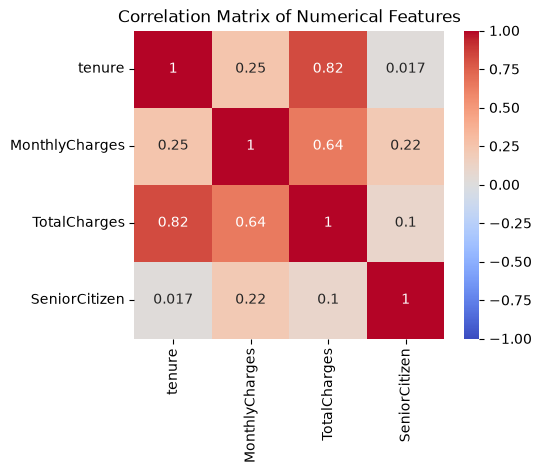

In [67]:
# Task 18 — correlation matrix and heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_matrix = df_clean[numeric_cols].corr(numeric_only=True)
print(corr_matrix.round(2))

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Answer 18 (most correlated pairs):**
_`tenure` and `TotalCharges` are strongly positively correlated (correlation around 0.83), which makes sense since `TotalCharges` naturally grows the longer a customer stays. `MonthlyCharges` and `TotalCharges` are also moderately positively correlated. `SeniorCitizen` has a weak correlation with the other numerical features._

**Answer 19 (correlation vs. causation; potential problems):**
_Correlation does not imply causation — `tenure` and `TotalCharges` are related simply because `TotalCharges` is built from tenure and monthly charges over time, not because one directly "causes" the other in a business sense. Having two strongly correlated features like this can cause redundancy problems for some models (multicollinearity), where the model can't tell which of the two features is actually driving the prediction, so we may want to keep only one of them, or engineer a new feature from both._

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**

20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.

21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_`customerID` is purely an identifier with no predictive value and should be removed regardless of leakage. `TotalCharges` is borderline: it is technically known before churn happens (it's the amount billed so far), so it isn't leakage in the strict sense, but since it's mathematically derived from `tenure` × `MonthlyCharges`, it's mostly redundant information rather than new signal. There is no column in this dataset that is obviously only known *after* a customer has already churned (e.g. a "cancellation date" or "reason for leaving" column), so the main leakage risk here is low, but it's still worth double-checking any column that describes account status at the *end* of the relationship rather than during it._

**Answer 21 (what would go wrong):**
_If a column that is only known after churn happens were left in the model's inputs, the model would essentially be "cheating" — it would learn to associate that after-the-fact information with the churn outcome and appear extremely accurate during testing, but it would fail completely in a real deployment, because that information simply wouldn't exist yet when the company needs to predict churn for a current customer._

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per customer, no predictive value |
| gender | Categorical | Feature | Keep, clean formatting | Standardize whitespace/casing; weak predictor but harmless to keep |
| SeniorCitizen | Categorical (0/1) | Feature | Keep | Already numeric-coded, usable as-is |
| Partner | Categorical | Feature | Keep | May relate to household stability/churn |
| Dependents | Categorical | Feature | Keep | May relate to household stability/churn |
| tenure | Numerical | Feature | Keep | Strong relationship with churn found in EDA |
| PhoneService | Categorical | Feature | Keep | Describes subscribed services |
| MultipleLines | Categorical | Feature | Keep | Describes subscribed services |
| InternetService | Categorical | Feature | Keep, clean formatting | Standardize casing/whitespace; related to churn |
| OnlineSecurity | Categorical | Feature | Keep | Add-on service, may relate to satisfaction |
| OnlineBackup | Categorical | Feature | Keep | Add-on service, may relate to satisfaction |
| DeviceProtection | Categorical | Feature | Keep | Add-on service, may relate to satisfaction |
| TechSupport | Categorical | Feature | Keep | Add-on service, may relate to satisfaction |
| StreamingTV | Categorical | Feature | Keep | Add-on service |
| StreamingMovies | Categorical | Feature | Keep | Add-on service |
| Contract | Categorical | Feature | Keep | Strong relationship with churn found in EDA |
| PaperlessBilling | Categorical | Feature | Keep | Billing preference, minor relevance |
| PaymentMethod | Categorical | Feature | Keep, fill missing | Missing values filled with mode; related to churn |
| MonthlyCharges | Numerical | Feature | Keep, fill missing | Missing values filled with median; related to churn |
| TotalCharges | Numerical | Feature | Keep, convert & clean | Convert to numeric, fill blanks/missing based on tenure=0 logic; correlated with tenure so consider dropping later if redundant |
| Churn | Categorical | Target | Keep | This is the variable we want to predict |


---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**

23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.

24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [68]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Fix text formatting
clean_df['gender'] = clean_df['gender'].str.strip()
clean_df['InternetService'] = clean_df['InternetService'].str.strip().str.title()

# Fix TotalCharges dtype and missing/blank values
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df.loc[(clean_df['TotalCharges'].isnull()) & (clean_df['tenure'] == 0), 'TotalCharges'] = 0
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(clean_df['TotalCharges'].median())

# Fill remaining missing values
clean_df['PaymentMethod'] = clean_df['PaymentMethod'].fillna(clean_df['PaymentMethod'].mode()[0])
clean_df['InternetService'] = clean_df['InternetService'].fillna(clean_df['InternetService'].mode()[0])
clean_df['MonthlyCharges'] = clean_df['MonthlyCharges'].fillna(clean_df['MonthlyCharges'].median())

# Remove duplicates
clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset='customerID', keep='last')

# Drop the identifier column (not a predictive feature)
clean_df = clean_df.drop(columns=['customerID'])

clean_df = clean_df.reset_index(drop=True)

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)

clean_df.shape

(7043, 20)

In [69]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()
print()
print("Missing values:\n", clean_df.isnull().sum().sum())
print("Duplicated rows:", clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: _The target variable `Churn` is imbalanced._
- Evidence: _About 73% of customers are "No" and 27% are "Yes"._
- Interpretation: _Future model evaluation (Lab 3) shouldn't rely on accuracy alone, since a model could score well just by always predicting "No"._

**Finding 2**
- Observation: _Customers on month-to-month contracts churn far more than customers on longer contracts._
- Evidence: _Crosstab of `Contract` vs `Churn` showed a much higher churn percentage for the month-to-month group._
- Interpretation: _`Contract` is likely to be one of the strongest predictors of churn._

**Finding 3**
- Observation: _New customers (low tenure) churn much more than long-term customers._
- Evidence: _The boxplot of `tenure` by `Churn` showed a clearly lower median tenure for churned customers._
- Interpretation: _The first few months of service seem critical — the company may want to focus retention efforts early in the customer lifecycle._

**Finding 4**
- Observation: _`TotalCharges` was stored as text and had blank values instead of numbers._
- Evidence: _`df['TotalCharges'].dtype` was `object`, and blank string values corresponded to customers with `tenure` = 0._
- Interpretation: _Simple `.dtypes` checks and `.unique()`/sampling of a column are essential before trusting any column, even numeric-looking ones._

**Finding 5**
- Observation: _`tenure` and `TotalCharges` are strongly correlated._
- Evidence: _Correlation matrix showed a coefficient of roughly 0.83 between them._
- Interpretation: _These two features carry overlapping information, so a future model may only need one of them (or an engineered combination) to avoid redundancy._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _The `TotalCharges` column being stored as text with blank values instead of numbers — if left unfixed, this column would have been unusable in any numeric calculation or model._

2. What was the most interesting pattern you discovered?
   _How strongly contract type and tenure are related to churn — customers on month-to-month contracts with low tenure churn much more than everyone else._

3. Which feature seems most useful for predicting churn?
   _`Contract`, since it showed the clearest difference in churn rate across its categories._

4. Which feature should probably not be used, and why?
   _`customerID`, since it's a unique identifier with no real relationship to churn._

5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _Categorical columns will need to be encoded into numbers (e.g. one-hot encoding), numerical features may need scaling, and the class imbalance in `Churn` may need to be addressed (e.g. through resampling or class weights) before training a model._
   
6. What would you do next if you had another 3 hours?
   _I would dig deeper into combinations of features (e.g. contract type + tenure together), look for feature-engineering opportunities like grouping tenure into bins, and investigate whether the add-on service columns (OnlineSecurity, TechSupport, etc.) combine into a meaningful "number of services" feature._


---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [71]:
# Bonus — optional exploration
# Churn rate across a combination of 2 customer segments: Contract + InternetService
bonus = pd.crosstab([df_clean['Contract'], df_clean['InternetService']], df_clean['Churn'], normalize='index') * 100
print(bonus.round(2))

# Possible feature-engineering opportunity: count of subscribed add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_clean['num_addon_services'] = (df_clean[addon_cols] == 'Yes').sum(axis=1)
print()
print(df_clean.groupby('Churn')['num_addon_services'].mean())

Churn                              No    Yes
Contract       InternetService              
Month-to-month Dsl              67.75  32.25
               Fiber Optic      45.68  54.32
               No               81.27  18.73
One year       Dsl              90.86   9.14
               Fiber Optic      80.99  19.01
               No               97.73   2.27
Two year       Dsl              98.06   1.94
               Fiber Optic      93.06   6.94
               No               99.21   0.79

Churn
No     2.135292
Yes    1.768325
Name: num_addon_services, dtype: float64


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook